In [1]:
import sys
print(sys.executable)

C:\Users\taddi\OneDrive\Desktop\legal-assistant\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset/legal_cases.csv")

df.head()

,case_id,case_type,legal_category,court,year,case_duration_months,previous_status,outcome
0,1,Civil,Property,District Court,2021,18,Pending,Pending
1,2,Criminal,Criminal Law,High Court,2021,10,Pending,Convicted
2,3,Civil,Family,District Court,2022,24,Pending,Settled
3,4,Criminal,Criminal Law,High Court,2022,14,Pending,Acquitted
4,5,Civil,Property,District Court,2023,30,Pending,Settled


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   case_id               15 non-null     int64
 1   case_type             15 non-null     str  
 2   legal_category        15 non-null     str  
 3   court                 15 non-null     str  
 4   year                  15 non-null     int64
 5   case_duration_months  15 non-null     int64
 6   previous_status       15 non-null     str  
 7   outcome               15 non-null     str  
dtypes: int64(3), str(5)
memory usage: 1.1 KB


In [5]:
df.isnull().sum()

case_id                 0
case_type               0
legal_category          0
court                   0
year                    0
case_duration_months    0
previous_status         0
outcome                 0
dtype: int64

In [6]:
df["legal_category"].value_counts()

legal_category
Property        5
Criminal Law    4
Family          4
Cyber Crime     2
Name: count, dtype: int64

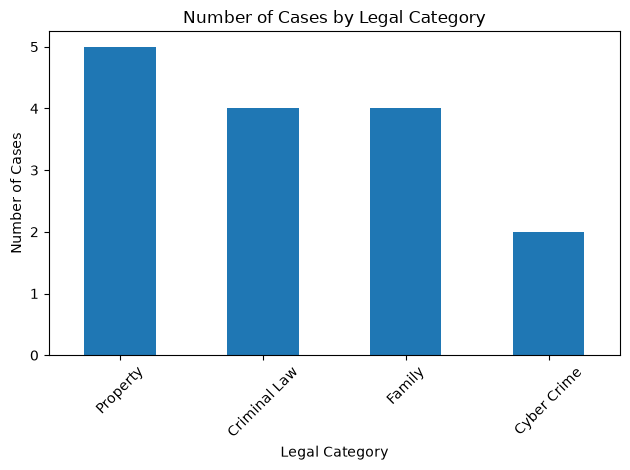

In [7]:
df["legal_category"].value_counts().plot(kind="bar")

plt.title("Number of Cases by Legal Category")
plt.xlabel("Legal Category")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
avg_duration = df.groupby("legal_category")["case_duration_months"].mean()

print(avg_duration)

legal_category
Criminal Law    12.75
Cyber Crime      7.50
Family          15.00
Property        23.60
Name: case_duration_months, dtype: float64


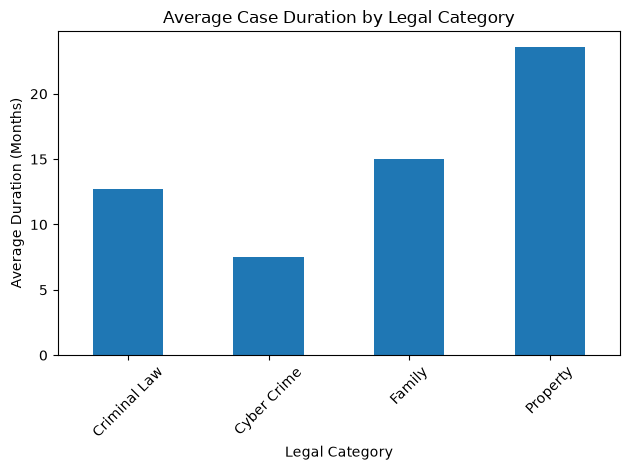

In [9]:
avg_duration.plot(kind="bar")

plt.title("Average Case Duration by Legal Category")
plt.xlabel("Legal Category")
plt.ylabel("Average Duration (Months)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df["outcome"].value_counts()

outcome
Settled      7
Convicted    3
Acquitted    3
Pending      2
Name: count, dtype: int64

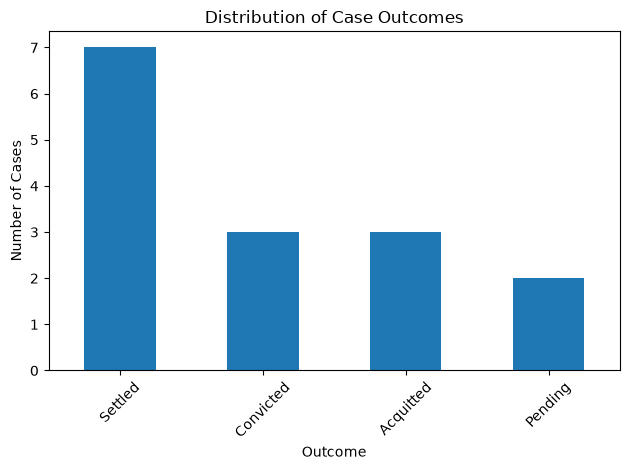

In [11]:
df["outcome"].value_counts().plot(kind="bar")

plt.title("Distribution of Case Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
outcome_by_category = pd.crosstab(
    df["legal_category"],
    df["outcome"]
)

outcome_by_category

outcome,Acquitted,Convicted,Pending,Settled
legal_category,,,,
Criminal Law,1,3,0,0
Cyber Crime,2,0,0,0
Family,0,0,0,4
Property,0,0,2,3


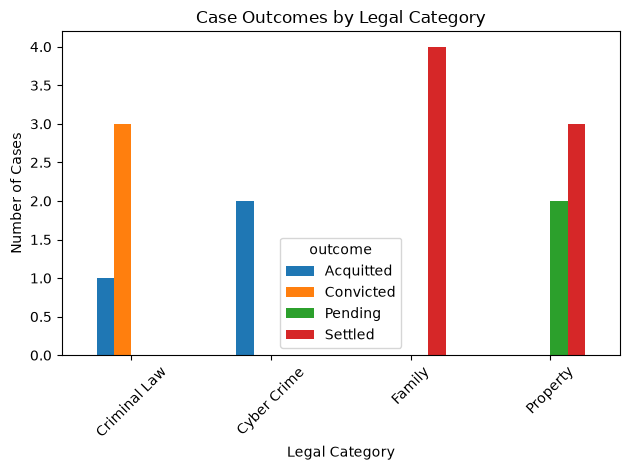

In [13]:
outcome_by_category.plot(kind="bar")

plt.title("Case Outcomes by Legal Category")
plt.xlabel("Legal Category")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=["case_id", "outcome"])
y = df["outcome"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
  case_type legal_category           court  year  case_duration_months  \
0     Civil       Property  District Court  2021                    18   
1  Criminal   Criminal Law      High Court  2021                    10   
2     Civil         Family  District Court  2022                    24   
3  Criminal   Criminal Law      High Court  2022                    14   
4     Civil       Property  District Court  2023                    30   

  previous_status  
0         Pending  
1         Pending  
2         Pending  
3         Pending  
4         Pending  

Target:
0      Pending
1    Convicted
2      Settled
3    Acquitted
4      Settled
Name: outcome, dtype: str


In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15, 6)
y shape: (15,)


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "case_type",
    "legal_category",
    "court",
    "previous_status"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10, 6)
Testing data: (5, 6)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [23]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Acquitted','Convicted','Pending','Settled']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['case_type','legal_category','court','year','case_duration_months', 'previous_status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dr

In [24]:
y_pred = model.predict(X_test)

print("Actual outcomes:")
print(y_test.values)

print("\nPredicted outcomes:")
print(y_pred)

Actual outcomes:
<StringArray>
['Settled', 'Pending', 'Acquitted', 'Settled', 'Convicted']
Length: 5, dtype: str

Predicted outcomes:
['Settled' 'Settled' 'Acquitted' 'Settled' 'Convicted']


In [26]:
y_pred = model.predict(X_test)

print("Actual outcomes:")
print(y_test.values)

print("\nPredicted outcomes:")
print(y_pred)

Actual outcomes:
<StringArray>
['Settled', 'Pending', 'Acquitted', 'Settled', 'Convicted']
Length: 5, dtype: str

Predicted outcomes:
['Settled' 'Settled' 'Acquitted' 'Settled' 'Convicted']


In [27]:
y_pred = model.predict(X_test)

print("Actual outcomes:")
print(y_test.values)

print("\nPredicted outcomes:")
print(y_pred)

Actual outcomes:
<StringArray>
['Settled', 'Pending', 'Acquitted', 'Settled', 'Convicted']
Length: 5, dtype: str

Predicted outcomes:
['Settled' 'Settled' 'Acquitted' 'Settled' 'Convicted']


In [28]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

   Acquitted       1.00      1.00      1.00         1
   Convicted       1.00      1.00      1.00         1
     Pending       0.00      0.00      0.00         1
     Settled       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.67      0.75      0.70         5
weighted avg       0.67      0.80      0.72         5



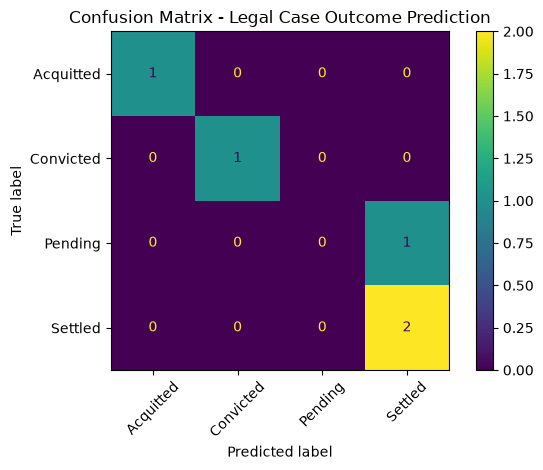

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Legal Case Outcome Prediction")
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 300

case_types = ["Civil", "Criminal"]
legal_categories = ["Property", "Criminal Law", "Family", "Cyber Crime"]
courts = ["District Court", "High Court", "Family Court"]
statuses = ["Pending", "Under Review", "Hearing"]

data = {
    "case_id": range(1, n + 1),
    "case_type": np.random.choice(case_types, n),
    "legal_category": np.random.choice(
        legal_categories,
        n,
        p=[0.30, 0.30, 0.25, 0.15]
    ),
    "court": np.random.choice(courts, n),
    "year": np.random.randint(2020, 2026, n),
    "case_duration_months": np.random.randint(3, 49, n),
    "previous_status": np.random.choice(statuses, n)
}

df_large = pd.DataFrame(data)

# Generate outcome based partly on case characteristics
def generate_outcome(row):
    if row["previous_status"] == "Pending":
        probabilities = [0.45, 0.15, 0.25, 0.15]
    elif row["case_duration_months"] > 30:
        probabilities = [0.50, 0.15, 0.20, 0.15]
    elif row["legal_category"] == "Criminal Law":
        probabilities = [0.15, 0.45, 0.20, 0.20]
    elif row["legal_category"] == "Cyber Crime":
        probabilities = [0.30, 0.20, 0.40, 0.10]
    else:
        probabilities = [0.10, 0.10, 0.15, 0.65]

    return np.random.choice(
        ["Settled", "Convicted", "Acquitted", "Pending"],
        p=probabilities
    )

df_large["outcome"] = df_large.apply(generate_outcome, axis=1)

df_large.head()

,case_id,case_type,legal_category,court,year,case_duration_months,previous_status,outcome
0,1,Civil,Cyber Crime,District Court,2020,31,Pending,Acquitted
1,2,Criminal,Property,High Court,2020,45,Pending,Acquitted
2,3,Civil,Property,Family Court,2025,24,Under Review,Pending
3,4,Civil,Criminal Law,Family Court,2021,28,Under Review,Acquitted
4,5,Civil,Cyber Crime,High Court,2025,30,Under Review,Acquitted


In [31]:
print("Dataset shape:", df_large.shape)
print("\nOutcome distribution:")
print(df_large["outcome"].value_counts())

Dataset shape: (300, 8)

Outcome distribution:
outcome
Settled      107
Pending       75
Acquitted     72
Convicted     46
Name: count, dtype: int64


In [32]:
df_large.to_csv("../dataset/legal_cases_large.csv", index=False)

print("Large dataset saved successfully!")

Large dataset saved successfully!


In [33]:
import pandas as pd

df = pd.read_csv("../dataset/legal_cases_large.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (300, 8)


,case_id,case_type,legal_category,court,year,case_duration_months,previous_status,outcome
0,1,Civil,Cyber Crime,District Court,2020,31,Pending,Acquitted
1,2,Criminal,Property,High Court,2020,45,Pending,Acquitted
2,3,Civil,Property,Family Court,2025,24,Under Review,Pending
3,4,Civil,Criminal Law,Family Court,2021,28,Under Review,Acquitted
4,5,Civil,Cyber Crime,High Court,2025,30,Under Review,Acquitted


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   case_id               300 non-null    int64
 1   case_type             300 non-null    str  
 2   legal_category        300 non-null    str  
 3   court                 300 non-null    str  
 4   year                  300 non-null    int64
 5   case_duration_months  300 non-null    int64
 6   previous_status       300 non-null    str  
 7   outcome               300 non-null    str  
dtypes: int64(3), str(5)
memory usage: 18.9 KB


In [35]:
df["outcome"].value_counts()

outcome
Settled      107
Pending       75
Acquitted     72
Convicted     46
Name: count, dtype: int64

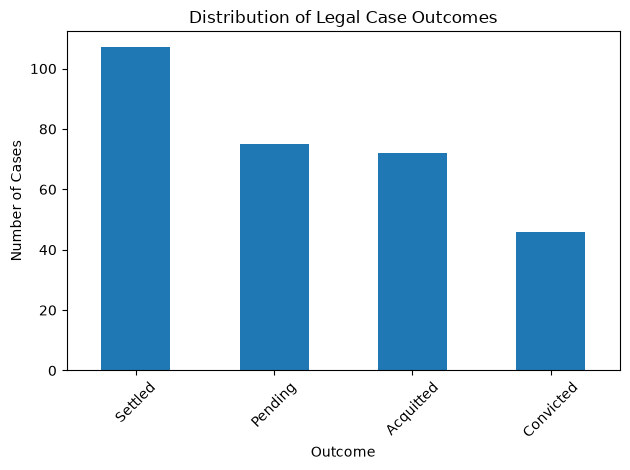

In [36]:
df["outcome"].value_counts().plot(kind="bar")

plt.title("Distribution of Legal Case Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
df["legal_category"].value_counts()

legal_category
Property        88
Family          84
Criminal Law    80
Cyber Crime     48
Name: count, dtype: int64

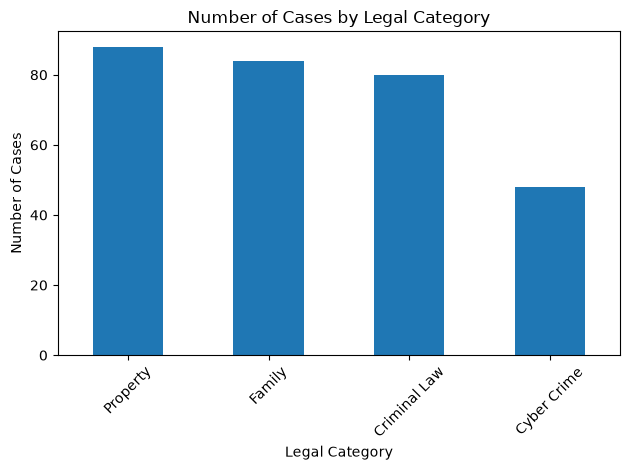

In [38]:
df["legal_category"].value_counts().plot(kind="bar")

plt.title("Number of Cases by Legal Category")
plt.xlabel("Legal Category")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
df["legal_category"].value_counts()

legal_category
Property        88
Family          84
Criminal Law    80
Cyber Crime     48
Name: count, dtype: int64

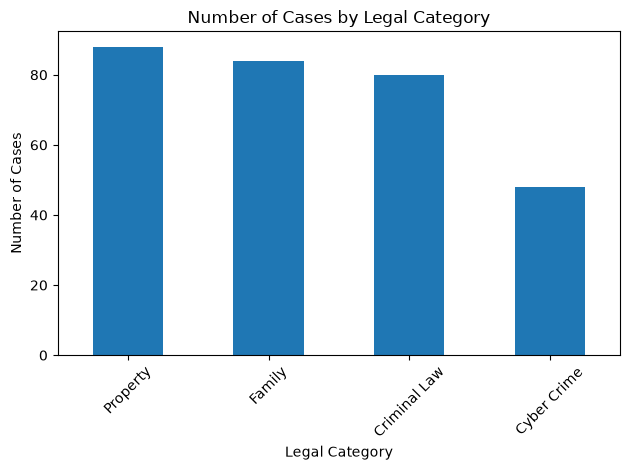

In [40]:
df["legal_category"].value_counts().plot(kind="bar")

plt.title("Number of Cases by Legal Category")
plt.xlabel("Legal Category")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [41]:
avg_duration = df.groupby("legal_category")["case_duration_months"].mean()

print(avg_duration)

legal_category
Criminal Law    24.800000
Cyber Crime     23.645833
Family          27.559524
Property        27.727273
Name: case_duration_months, dtype: float64


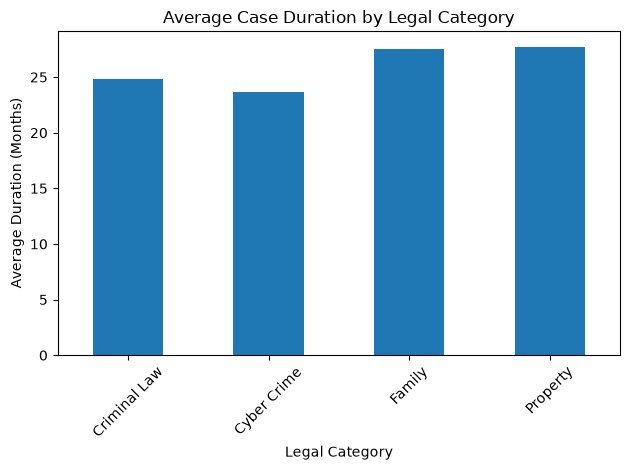

In [42]:
avg_duration.plot(kind="bar")

plt.title("Average Case Duration by Legal Category")
plt.xlabel("Legal Category")
plt.ylabel("Average Duration (Months)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
X = df.drop(columns=["case_id", "outcome"])
y = df["outcome"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (300, 6)
Target: (300,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 6)
Testing data: (60, 6)


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [46]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [47]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 60


In [48]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 33.33 %

Classification Report:
              precision    recall  f1-score   support

   Acquitted       0.14      0.20      0.17        15
   Convicted       0.00      0.00      0.00         9
     Pending       0.50      0.47      0.48        15
     Settled       0.42      0.48      0.44        21

    accuracy                           0.33        60
   macro avg       0.26      0.29      0.27        60
weighted avg       0.31      0.33      0.32        60



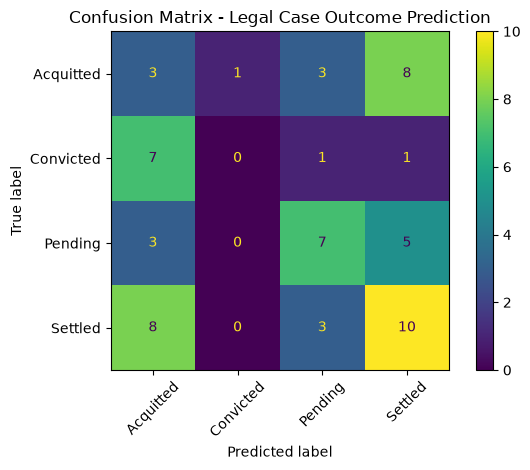

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Legal Case Outcome Prediction")
plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 33.33 %

Classification Report:
              precision    recall  f1-score   support

   Acquitted       0.14      0.20      0.17        15
   Convicted       0.00      0.00      0.00         9
     Pending       0.50      0.47      0.48        15
     Settled       0.42      0.48      0.44        21

    accuracy                           0.33        60
   macro avg       0.26      0.29      0.27        60
weighted avg       0.31      0.33      0.32        60



In [51]:
import pandas as pd

rf = model.named_steps["classifier"]

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance)


remainder__case_duration_months              0.339154
remainder__year                              0.197296
categorical__court_Family Court              0.044914
categorical__legal_category_Criminal Law     0.043766
categorical__previous_status_Hearing         0.042339
categorical__court_District Court            0.041559
categorical__previous_status_Pending         0.041182
categorical__previous_status_Under Review    0.039774
categorical__court_High Court                0.039526
categorical__legal_category_Property         0.039483
categorical__case_type_Criminal              0.035517
categorical__legal_category_Family           0.034381
categorical__legal_category_Cyber Crime      0.031255
categorical__case_type_Civil                 0.029855
dtype: float64


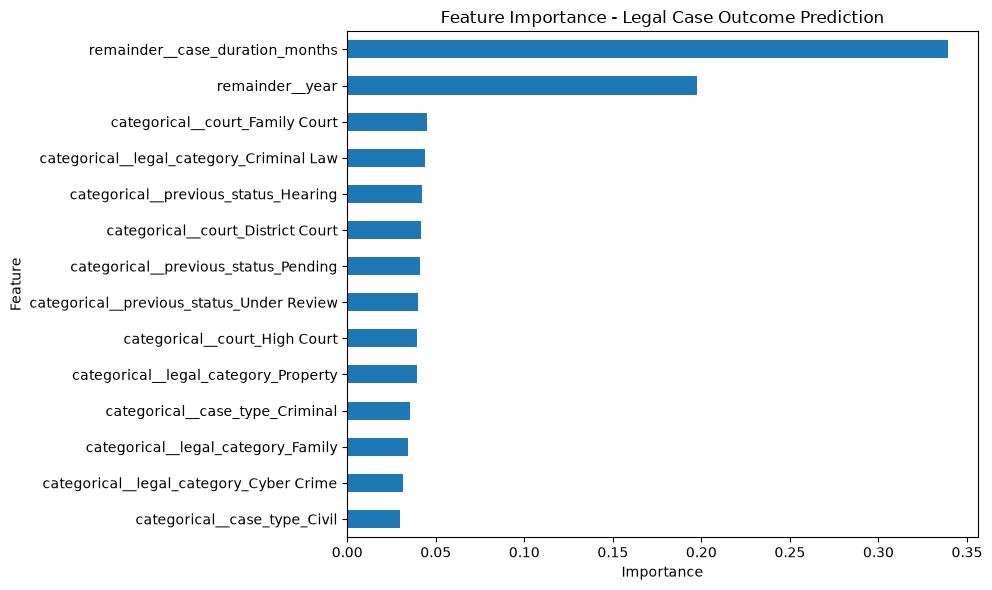

In [53]:
importance.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Feature Importance - Legal Case Outcome Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [54]:
X = df.drop(columns=[
    "case_id",
    "outcome",
    "case_duration_months"
])

y = df["outcome"]

print("Features:", X.columns.tolist())
print("Feature shape:", X.shape)

Features: ['case_type', 'legal_category', 'court', 'year', 'previous_status']
Feature shape: (300, 5)


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "case_type",
    "legal_category",
    "court",
    "previous_status"
]

numeric_features = [
    "year"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 5)
Testing data: (60, 5)


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

print("Improved Random Forest model created!")

Improved Random Forest model created!


In [58]:
model_v2.fit(X_train, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [59]:
y_pred_v2 = model_v2.predict(X_test)

print("Predictions generated:", len(y_pred_v2))

Predictions generated: 60


In [60]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_v2 = accuracy_score(y_test, y_pred_v2)

print("V2 Model Accuracy:", round(accuracy_v2 * 100, 2), "%")

print("\nV2 Classification Report:")
print(classification_report(y_test, y_pred_v2, zero_division=0))

V2 Model Accuracy: 21.67 %

V2 Classification Report:
              precision    recall  f1-score   support

   Acquitted       0.17      0.27      0.21        15
   Convicted       0.00      0.00      0.00         9
     Pending       0.38      0.40      0.39        15
     Settled       0.18      0.14      0.16        21

    accuracy                           0.22        60
   macro avg       0.18      0.20      0.19        60
weighted avg       0.20      0.22      0.20        60



In [61]:
print(classification_report(y_test, y_pred_v2, zero_division=0))

              precision    recall  f1-score   support

   Acquitted       0.17      0.27      0.21        15
   Convicted       0.00      0.00      0.00         9
     Pending       0.38      0.40      0.39        15
     Settled       0.18      0.14      0.16        21

    accuracy                           0.22        60
   macro avg       0.18      0.20      0.19        60
weighted avg       0.20      0.22      0.20        60



In [62]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

case_types = ["Civil", "Criminal"]
legal_categories = ["Property", "Criminal Law", "Family", "Cyber Crime"]
courts = ["District Court", "High Court", "Family Court"]
previous_statuses = ["Pending", "Under Review", "Hearing", "Mediation"]

rows = []

for case_id in range(1, n + 1):

    case_type = np.random.choice(case_types)
    legal_category = np.random.choice(
        legal_categories,
        p=[0.30, 0.30, 0.25, 0.15]
    )
    court = np.random.choice(courts)
    year = np.random.randint(2020, 2026)
    case_duration = np.random.randint(3, 49)
    previous_status = np.random.choice(previous_statuses)

    # Base probabilities
    probabilities = {
        "Settled": 0.25,
        "Convicted": 0.25,
        "Acquitted": 0.25,
        "Pending": 0.25
    }

    # Create meaningful relationships between features and outcome

    if legal_category == "Family":
        probabilities["Settled"] += 0.35

    if legal_category == "Property":
        probabilities["Settled"] += 0.20
        probabilities["Pending"] += 0.15

    if legal_category == "Criminal Law":
        probabilities["Convicted"] += 0.30
        probabilities["Acquitted"] += 0.15

    if legal_category == "Cyber Crime":
        probabilities["Acquitted"] += 0.30
        probabilities["Convicted"] += 0.15

    if previous_status == "Mediation":
        probabilities["Settled"] += 0.35

    if previous_status == "Pending":
        probabilities["Pending"] += 0.35

    if previous_status == "Hearing" and legal_category == "Criminal Law":
        probabilities["Convicted"] += 0.30

    if previous_status == "Under Review":
        probabilities["Pending"] += 0.20

    # Long-running cases are more likely to remain pending
    if case_duration > 30:
        probabilities["Pending"] += 0.25

    # Normalize probabilities
    total = sum(probabilities.values())

    probabilities = {
        key: value / total
        for key, value in probabilities.items()
    }

    outcome = np.random.choice(
        list(probabilities.keys()),
        p=list(probabilities.values())
    )

    rows.append([
        case_id,
        case_type,
        legal_category,
        court,
        year,
        case_duration,
        previous_status,
        outcome
    ])

df_improved = pd.DataFrame(
    rows,
    columns=[
        "case_id",
        "case_type",
        "legal_category",
        "court",
        "year",
        "case_duration_months",
        "previous_status",
        "outcome"
    ]
)

print("Improved dataset created!")
print("Shape:", df_improved.shape)

df_improved.head()

Improved dataset created!
Shape: (500, 8)


,case_id,case_type,legal_category,court,year,case_duration_months,previous_status,outcome
0,1,Civil,Family,Family Court,2022,10,Pending,Acquitted
1,2,Criminal,Property,Family Court,2022,26,Pending,Pending
2,3,Criminal,Family,District Court,2021,26,Mediation,Pending
3,4,Criminal,Property,District Court,2020,14,Under Review,Acquitted
4,5,Criminal,Property,Family Court,2022,44,Mediation,Settled


In [63]:
print(df_improved["outcome"].value_counts())

outcome
Pending      160
Settled      144
Convicted    102
Acquitted     94
Name: count, dtype: int64


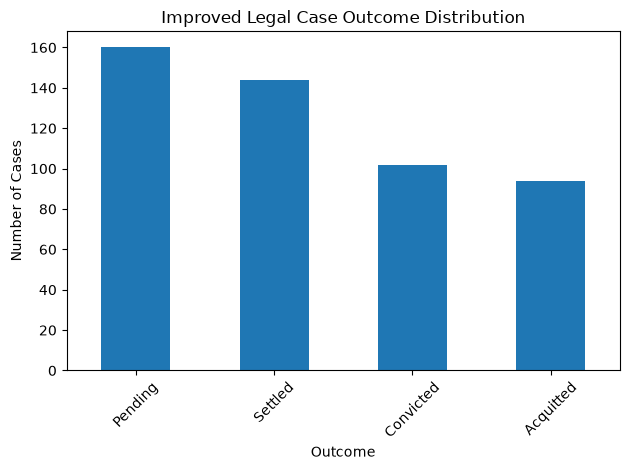

In [64]:
df_improved["outcome"].value_counts().plot(kind="bar")

plt.title("Improved Legal Case Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
df_improved.to_csv(
    "../dataset/legal_cases_improved.csv",
    index=False
)

print("Improved dataset saved successfully!")

Improved dataset saved successfully!


In [66]:
df_improved.to_csv(
    "../dataset/legal_cases_improved.csv",
    index=False
)

print("Improved dataset saved successfully!")

Improved dataset saved successfully!


In [67]:
df = pd.read_csv("../dataset/legal_cases_improved.csv")

print("Final dataset:", df.shape)
df.head()

Final dataset: (500, 8)


,case_id,case_type,legal_category,court,year,case_duration_months,previous_status,outcome
0,1,Civil,Family,Family Court,2022,10,Pending,Acquitted
1,2,Criminal,Property,Family Court,2022,26,Pending,Pending
2,3,Criminal,Family,District Court,2021,26,Mediation,Pending
3,4,Criminal,Property,District Court,2020,14,Under Review,Acquitted
4,5,Criminal,Property,Family Court,2022,44,Mediation,Settled


In [68]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["case_id", "outcome"])
y = df["outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (400, 6)
Testing: (100, 6)


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

categorical_features = [
    "case_type",
    "legal_category",
    "court",
    "previous_status"
]

numeric_features = [
    "year",
    "case_duration_months"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

final_model.fit(X_train, y_train)

print("FINAL MODEL TRAINED SUCCESSFULLY!")

FINAL MODEL TRAINED SUCCESSFULLY!


In [70]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_final = final_model.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred_final)

print("Final Model Accuracy:",
      round(accuracy_final * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    zero_division=0
))    

Final Model Accuracy: 31.0 %

Classification Report:
              precision    recall  f1-score   support

   Acquitted       0.27      0.16      0.20        19
   Convicted       0.29      0.25      0.27        20
     Pending       0.28      0.34      0.31        32
     Settled       0.38      0.41      0.39        29

    accuracy                           0.31       100
   macro avg       0.30      0.29      0.29       100
weighted avg       0.31      0.31      0.30       100



In [71]:
import joblib

joblib.dump(
    final_model,
    "../models/legal_case_outcome_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
